In [93]:
import os
import random
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import scipy 
from scipy.stats import randint
import pickle
import joblib
from scipy import stats
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, mutual_info_classif, SelectKBest

In [11]:
file_path = r"D:\Git Repositories\AuctionScout-AI-powered-player-recommendations-for-IPL-auctions\dataset\batsman_df_labeled.csv"
df = pd.read_csv(file_path)

In [15]:
df.shape

(295, 8)

In [23]:
X = df.iloc[:,1:7]
y = df.iloc[:,7]

In [101]:
pipeline = ImbPipeline(steps=[
    ('scaling', RobustScaler()),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=4)),
    ('undersampling', RandomUnderSampler(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=144, min_samples_split= 17, max_features="log2", min_samples_leaf=11, max_depth=70, criterion='entropy',class_weight="balanced",random_state=42))
])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print("Mean CV Accuracy:", np.mean(scores))

Mean CV Accuracy: 0.7796610169491526


In [102]:
scores

array([0.69491525, 0.81355932, 0.77966102, 0.79661017, 0.81355932])

In [103]:
mean_score = np.mean(scores)
std_score = np.std(scores)

print(f"Mean Accuracy: {mean_score:.4f}")
print(f"Standard Deviation: {std_score:.4f}")

Mean Accuracy: 0.7797
Standard Deviation: 0.0442


In [81]:
params = {
    "classifier__n_estimators" : randint(1, 200),
    "classifier__max_depth" : randint(1, 100),
    "classifier__min_samples_split" : randint(2, 20),
    "classifier__min_samples_leaf" : randint (1, 50),
    "classifier__criterion" : ['gini', 'entropy', 'log_loss'],
    "classifier__max_features" : ['sqrt', 'log2', None],
    "classifier__class_weight" : ["balanced", "balanced_subsample"]
}

In [82]:
rv_search = RandomizedSearchCV(pipeline, 
                   params,
                   n_iter=50,
                   cv=10,
                   n_jobs=-1,
                   verbose=3,
                   random_state=42
                  )
                   
           

In [83]:
rv_search.fit(X, y)


Fitting 10 folds for each of 50 candidates, totalling 500 fits


RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('scaling', RobustScaler()),
                                             ('feature_selection',
                                              SelectKBest(k=4,
                                                          score_func=<function mutual_info_classif at 0x00000206FD657D00>)),
                                             ('undersampling',
                                              RandomUnderSampler(random_state=42)),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'classifier__class_w...
                                        'classifier__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000206868C17E0>,
                                        'classifier__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000020687445A80>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000020687461030>},
                   random_state=42, verbose=3)

In [84]:
print("Best paramters: ", rv_search.best_params_)
print("Best score: ", rv_search.best_score_)

Best paramters:  {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 70, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 11, 'classifier__min_samples_split': 17, 'classifier__n_estimators': 144}
Best score:  0.7965517241379311


# Feature Engineering

In [33]:
def Robust_Scaler(data):
    scaler_dir = r"D:\Git Repositories\AuctionScout-AI-powered-player-recommendations-for-IPL-auctions\notebooks\model_training\scaler_objects_batsman"
    scaler_file= [file for file in os.listdir(scaler_dir) if file.endswith(".pkl")]
    if scaler_file:
        scaler_path = os.path.join(scaler_dir, scaler_file[0])
        scaler = joblib.load(scaler_path)
        scaled_values = scaler.transform(data)
    else:
        scaler = RobustScaler()
        scaled_values = scaler.fit_transform(data)
        joblib.dump(scaler, f"{os.getcwd()}/scaler_objects/robust_scaler.pkl")

    
    scaled_df = pd.DataFrame(scaled_values, columns=data.columns, index=data.index)
    
    return scaled_df

In [27]:
def Label_encoding(data):
    encoder_dir = r"D:\Git Repositories\AuctionScout-AI-powered-player-recommendations-for-IPL-auctions\notebooks\model_training\encoder_objects_batsman"
    encoder_file= [file for file in os.listdir(encoder_dir) if file.endswith(".pkl")]
    if encoder_file:
       encoder_path = os.path.join(encoder_dir, encoder_file[0])
       encoder = joblib.load(encoder_path)
       encoded_values = encoder.transform(data)
    else:
        encoder = LabelEncoder()
        encoded_values = encoder.fit_transform(data)
        joblib.dump(encoder, f"{os.getcwd()}/encoder_objects/label_encoder.pkl")

    
    return encoded_values

In [34]:
scaled_predictor_variable = Robust_Scaler(X)

In [35]:
encoded_target_variable = Label_encoding(y)

# Feature selection 
## using mutual info

In [49]:
mutual_info_values = mutual_info_classif(scaled_predictor_variable, encoded_target_variable)
mutual_info_score = pd.Series(mutual_info_values)
mutual_info_score.index = X.columns
mutual_info_score.sort_values(ascending=False)

Batting_SR            0.347399
runs_batsman          0.292451
ball                  0.278034
Batting_Average       0.244946
wickets_lost_count    0.212868
wickets_taken         0.092081
dtype: float64

In [53]:
X_dropped_columns = X.drop(columns=["wickets_lost_count", "wickets_taken"], axis=1)

# Checking for class imbalance if exists

In [39]:
category_count = pd.Series(y).value_counts()
category_count

Recommendation
DON'T BUY    191
BUY           55
MAYBE         49
Name: count, dtype: int64

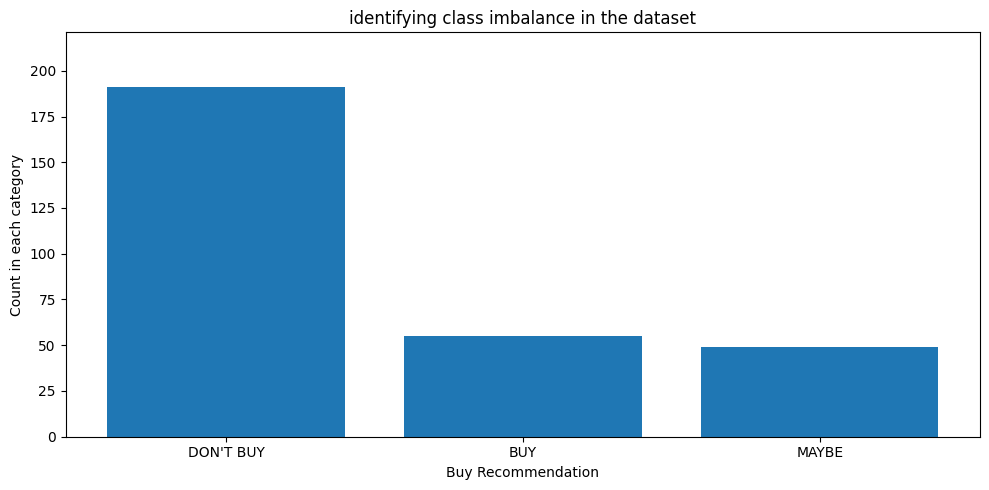

In [42]:
plt.figure(figsize=(10,5))
plt.bar(category_count.index, category_count.values)
plt.ylim(0, category_count.max() + 30)
plt.title("identifying class imbalance in the dataset")
plt.xlabel("Buy Recommendation")
plt.ylabel("Count in each category")
plt.tight_layout()
plt.show()

In [55]:
ran_under_sampler =RandomUnderSampler(random_state=42)
x_rus, y_rus = ran_under_sampler.fit_resample(X_dropped_columns, y)

In [56]:
resampled_class_counts = pd.Series(y_rus).value_counts()

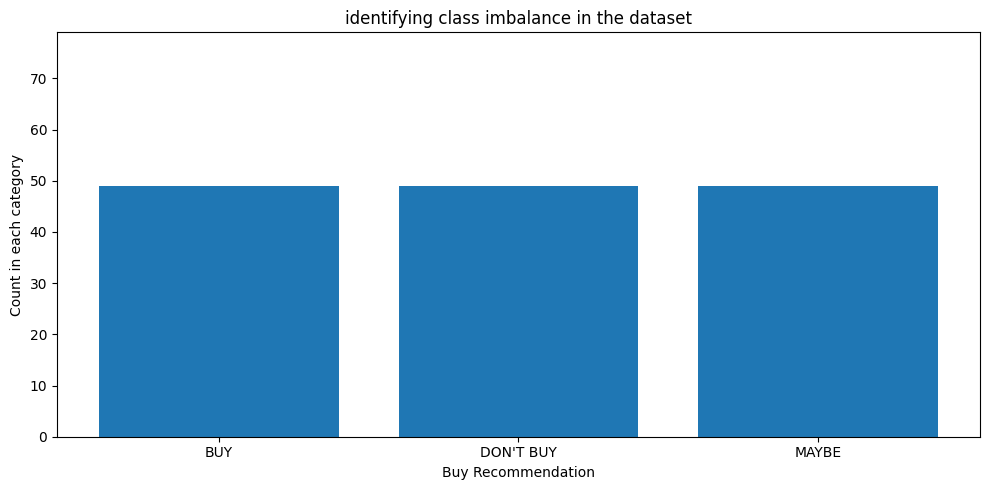

In [57]:
plt.figure(figsize=(10,5))
plt.bar(resampled_class_counts.index, resampled_class_counts.values)
plt.ylim(0, resampled_class_counts.max() + 30)
plt.title("identifying class imbalance in the dataset")
plt.xlabel("Buy Recommendation")
plt.ylabel("Count in each category")
plt.tight_layout()
plt.show()

In [58]:
x_rus

,runs_batsman,ball,Batting_SR,Batting_Average
137,1655,1244,133.04,26.27
24,509,388,131.19,28.28
149,173,136,127.21,19.22
58,92,79,116.46,15.33
90,1259,975,129.13,29.28
...,...,...,...,...
278,10,7,142.86,10.00
280,752,574,131.01,26.86
283,47,36,130.56,11.75
291,340,319,106.58,26.15


In [59]:
y_rus

137      BUY
24       BUY
149      BUY
58       BUY
90       BUY
       ...  
278    MAYBE
280    MAYBE
283    MAYBE
291    MAYBE
294    MAYBE
Name: Recommendation, Length: 147, dtype: object

In [60]:
model = RandomForestClassifier(random_state=42)

In [ ]:
params = {
    "n_estimators" : 
    
}

In [ ]:
ran_search_csv = RandomizedSearchCV(